# 小鼠矢状前脑与后脑切片

In [ ]:
from pathlib import Path
import sys
import warnings
warnings.filterwarnings("ignore")
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import torch

cwd = Path.cwd().resolve()
PROJECT_ROOT = next(
    (path for path in (cwd, *cwd.parents) if (path / "SpaDiff").is_dir()),
    cwd,
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import SpaDiff as sd
from SpaDiff.spatial import Neiber
from SpaDiff.utils import adjust_louvain_resolution, set_seed

In [2]:
SEED = 42
SLICE_ORDER = ["A", "P"]
REFERENCE_BATCH = "A"
N_CLUSTERS = 30
N_COMPONENTS = 50
N_NEIGHBORS = 10
K_INTRA = 6
K_INTER = 2
training_epochs = 300

# Change only MAX_ORDER to run the 0-4 order ablation.
MAX_ORDER = 2
SIMPLEX_ORDERS = (
    (0,) if MAX_ORDER == 0
    else tuple(range(1, MAX_ORDER + 1))
)
DSM_WEIGHTING = "variance"
# 三个论文主损失的外层权重：DSM、批次对齐、潜表示 KL。
DSM_LOSS_WEIGHT = 1.0
BATCH_LOSS_WEIGHT = 1.0
BATCH_POSTERIOR_SCALE = 1.0  # 第二项内部 q_phi(b|x0) 的辅助比例，不是第四项。
PRIOR_KL_LOSS_WEIGHT = 0.0  # SI practical setting.

DATA_ROOT = Path("E:/gxy_2/final/0_data/case2/")
print("DATA_ROOT =", DATA_ROOT)

set_seed(SEED)
torch.backends.cudnn.deterministic = True
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("device =", device)
print(f"loss weights: DSM={DSM_LOSS_WEIGHT}, batch={BATCH_LOSS_WEIGHT}, prior_KL={PRIOR_KL_LOSS_WEIGHT}")

DATA_ROOT = E:\gxy_2\final\0_data\case2
device = cuda:0
loss weights: DSM=1.0, batch=1.0, prior_KL=0.0


## 读取 Anterior/Posterior Visium 数据并对齐坐标

In [3]:
adata_a = sc.read_visium(DATA_ROOT / "Anterior")
adata_p = sc.read_visium(DATA_ROOT / "Posterior")
adata_a.var_names_make_unique()
adata_p.var_names_make_unique()

anterior_coord = np.asarray(adata_a.obsm["spatial"]).copy()
posterior_coord = np.asarray(adata_p.obsm["spatial"]).copy()
posterior_coord[:, 1] += anterior_coord[:, 1].min() - posterior_coord[:, 1].min()
posterior_coord[:, 0] += anterior_coord[:, 0].max() - posterior_coord[:, 0].min()
adata_p.obsm["spatial"] = posterior_coord

adata = sc.concat({"A": adata_a, "P": adata_p},join="inner", label="batch_name", index_unique="-")
adata.obs["batch_name"] = pd.Categorical(adata.obs["batch_name"], categories=SLICE_ORDER, ordered=True)
print(adata.obs["batch_name"].value_counts())

batch_name
P    3353
A    2696
Name: count, dtype: int64


## HVG、归一化与 PCA

In [4]:
adata.layers["counts"] = adata.X.copy()
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer="counts",n_top_genes=3000, batch_key="batch_name")
adata = adata[:, adata.var["highly_variable"]].copy()

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.scale(adata, max_value=10)

sc.tl.pca(adata, n_comps=50) # svd_solver="arpack"
features = torch.as_tensor(np.asarray(adata.obsm["X_pca"], dtype=np.float32), device=device)

## 构建单纯复形

In [5]:
# _, adjacency = Neiber(adata, k_intra=K_INTRA, k_inter=K_INTER, slice_order=SLICE_ORDER)
# adjacency = adjacency.maximum(adjacency.T)

coordinates = np.asarray(adata.obsm["spatial"])
knn = NearestNeighbors(n_neighbors=N_NEIGHBORS, metric="euclidean").fit(coordinates)
adjacency = knn.kneighbors_graph(coordinates, mode="connectivity")
adjacency.setdiag(0)
adjacency.eliminate_zeros()
adjacency = adjacency.maximum(adjacency.T)
operators = sd.to_torch_operators(sd.build_simplicial_operators(adjacency, max_order=MAX_ORDER), device=device)

batch_codes = adata.obs["batch_name"].cat.codes.to_numpy()
batch_ids = torch.as_tensor(batch_codes, dtype=torch.long, device=device)
modality_ids = torch.zeros(adata.n_obs, dtype=torch.long, device=device)

Simplicial complex statistics:
  order 0 (vertices): 6,049
  order 1 (edges): 29,353
  order 2 (triangles): 38,893


In [ ]:
print("operator nnz by order:", {order: operator._nnz() for order, operator in operators.items()})

operator nnz by order: {1: 64755, 2: 64735}


## 训练批次条件 VP-SDE

In [7]:
config = sd.SpaDiffConfig(
    data_dim=features.shape[1],
    condition_input_dim=features.shape[1],
    hidden_dim=128,
    topology_hidden_dim=64,
    topology_dim=64,
    score_depth=4,
    dropout=0.2,
    topology_projection_dropout=0.1,
    topology_residual=True,
    topology_output_normalization="feature",
    simplex_orders=SIMPLEX_ORDERS,
    propagation_steps=5,
    propagation_alpha=0.4,
    num_batches=len(SLICE_ORDER),
    num_modalities=1,
    num_scales=1000,
    dsm_weighting=DSM_WEIGHTING,
    dsm_weight=DSM_LOSS_WEIGHT,
    batch_alignment_weight=BATCH_LOSS_WEIGHT,
    batch_posterior_weight=BATCH_POSTERIOR_SCALE,
    prior_kl_weight=PRIOR_KL_LOSS_WEIGHT,
    batch_balanced_loss=True,
)
model = sd.SpaDiff(config).to(device)
training = sd.train_spadiff(
    model,
    target_features=features,
    operators=operators,
    batch_ids=batch_ids,
    modality_ids=modality_ids,
    condition_features=features,
    epochs=training_epochs,
    learning_rate=1e-3,
    weight_decay=1e-4,
    ema_decay=0.99,
    verbose_every=25,
)

Epoch 0001/300 | total=1.725520 | dsm=0.992475 | align=0.017770 | posterior=0.715275 | prior=-0.000000
Epoch 0025/300 | total=1.253456 | dsm=0.770196 | align=0.037881 | posterior=0.445379 | prior=-0.000000
Epoch 0050/300 | total=1.113836 | dsm=0.596817 | align=0.254059 | posterior=0.262959 | prior=-0.000000
Epoch 0075/300 | total=1.127301 | dsm=0.500239 | align=0.467915 | posterior=0.159147 | prior=0.000000
Epoch 0100/300 | total=0.753917 | dsm=0.440775 | align=0.196405 | posterior=0.116738 | prior=0.000000
Epoch 0125/300 | total=1.018145 | dsm=0.388042 | align=0.538199 | posterior=0.091903 | prior=-0.000000
Epoch 0150/300 | total=0.963531 | dsm=0.374391 | align=0.510864 | posterior=0.078276 | prior=-0.000000
Epoch 0175/300 | total=0.942817 | dsm=0.348788 | align=0.525094 | posterior=0.068935 | prior=-0.000000
Epoch 0200/300 | total=0.981472 | dsm=0.337507 | align=0.581974 | posterior=0.061991 | prior=-0.000000
Epoch 0225/300 | total=0.866917 | dsm=0.322445 | align=0.487890 | posterior

In [8]:
reference_code = SLICE_ORDER.index(REFERENCE_BATCH)
reference_batch_ids = torch.full_like(batch_ids, reference_code)
if training.ema is not None:
    training.ema.store(model.parameters())
    training.ema.copy_to(model.parameters())
try:
    model.eval()
    with torch.no_grad():
        topology_embedding = model.encode_condition(features,operators)
        harmonized_embedding= model.harmonize(
            observed_features=features,
            operators=operators,
            reference_batch_ids=reference_batch_ids,
            modality_ids=modality_ids,
            strength=0.10,
            guidance_scale=1.0,
            ode_steps=300,
        )
finally:
    if training.ema is not None:
        training.ema.restore(model.parameters())

adata.obsm["spadiff"] = topology_embedding.cpu().numpy()
adata.obsm["X_spadiff"] = harmonized_embedding.cpu().numpy()

## Louvain聚类与聚类结果可视化


In [9]:
adata = adjust_louvain_resolution(
    adata,
    target_n_clusters=N_CLUSTERS,
    use_rep="X_spadiff",
    key_added="louvain",
    n_neighbors=15,
    random_state=SEED,
    resolution_bounds=(0.01, 5.0),
    tolerance=0,
    max_iterations=25,
    verbose=True,
)
search = adata.uns["louvain_resolution_search"]
print("selected resolution =", search["selected_resolution"])
print("selected clusters =", search["selected_n_clusters"])

Adjusting Louvain toward 30 clusters.
Searching resolution in [0.01, 5] for 30 clusters...
  resolution=0.01 -> 1 clusters (target=30)
  resolution=5 -> 59 clusters (target=30)
  resolution=2.505 -> 38 clusters (target=30)
  resolution=1.2575 -> 28 clusters (target=30)
  resolution=1.88125 -> 32 clusters (target=30)
  resolution=1.56937 -> 31 clusters (target=30)
  resolution=1.41344 -> 29 clusters (target=30)
  resolution=1.49141 -> 29 clusters (target=30)
  resolution=1.53039 -> 29 clusters (target=30)
  resolution=1.54988 -> 30 clusters (target=30)
Selected resolution=1.54988: 30 clusters (target reached).
selected resolution = 1.5498828125
selected clusters = 30


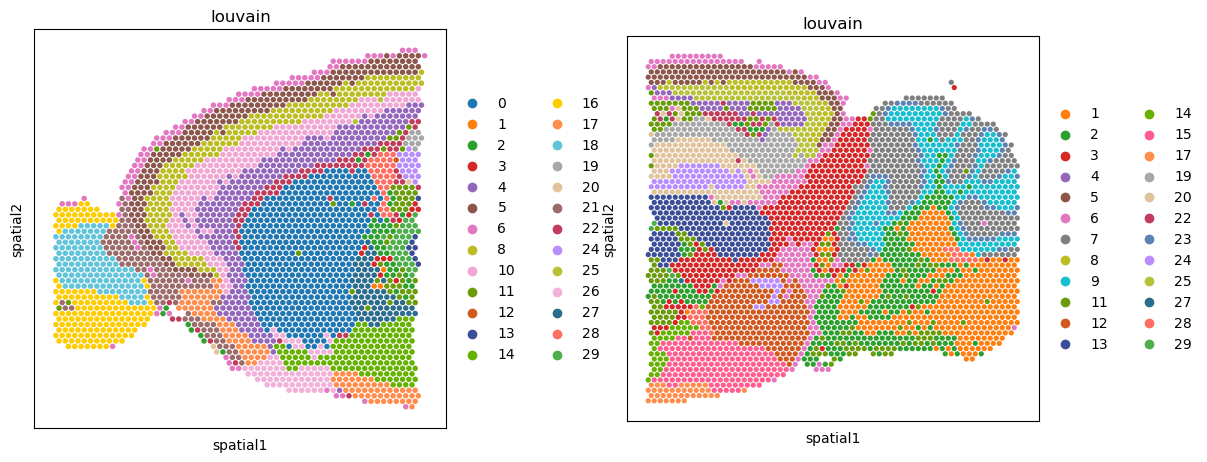

In [10]:
colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd",
    "#8c564b", "#e377c2", "#7f7f7f", "#bcbd22", "#17becf",
    "#f2a6d4", "#6a9c0a", "#d1581e", "#3b4e97", "#66b200",
    "#ff5c8f", "#ffcc00", "#ff8d4d", "#62c4da", "#a7a7a7",
    "#e1c39b", "#9c6c6c", "#c13b5b", "#5c82b3", "#ba8dff",
    "#b8c239", "#f2b1d9", "#2c6d8f", "#ff6f61", "#4daf4a",
]

plot_color = {str(i): c for i, c in enumerate(colors)}
fig, axes = plt.subplots(1, len(SLICE_ORDER), figsize=(12, 5))
for axis, sample in zip(np.atleast_1d(axes), SLICE_ORDER):
    subset = adata[adata.obs["batch_name"] == sample].copy()
    sc.pl.spatial(
        subset, img_key=None, color="louvain", ax=axis, show=False,
        spot_size=120, palette=plot_color, 
        # frameon=False, title=sample,legend_loc=None,
    )
plt.tight_layout()
plt.show()

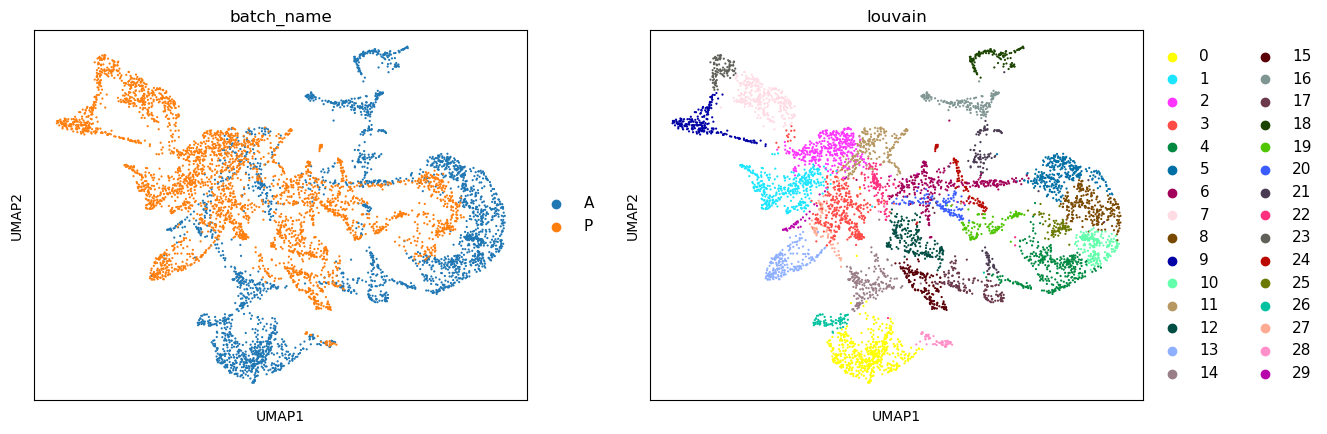

In [11]:
sc.tl.umap(adata, random_state=SEED)
sc.pl.umap(
    adata, color=["batch_name", "louvain"], size=10,
    legend_fontsize=11, legend_fontoutline=2,
)